In [13]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

groq_key = os.environ["GROQ_API_KEY"]
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGCHAIN_API_KEY')

llm = ChatGroq(model="openai/gpt-oss-20b", groq_api_key=groq_key)

In [14]:
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

class State(TypedDict):
    topic:str
    story_premise:str
    improved_story:str
    final_story:str

def generate_story(state:State):
    msg = llm.invoke(f"Write a one line story premise on the topic about {state['topic']}")
    return {"story_premise":msg.content}

def check(state:State):
    if "?" in state['story_premise'] or "!" in state['story_premise']:
        return "Fail"
    return "Pass"

def enhance_story(state:State):
    msg = llm.invoke(f"Add details, twists to make the plot interesting with this premise: {state['story_premise']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg = llm.invoke(f"Write a full story based on these details: {state['improved_story']}")
    return {"final_story":msg.content}

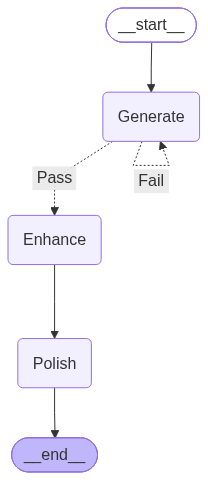

In [15]:
graph = StateGraph(State)

graph.add_node("Generate", generate_story)
graph.add_node("Enhance", enhance_story)
graph.add_node("Polish", polish_story)

graph.add_edge(START, "Generate")
graph.add_conditional_edges("Generate", check, {"Pass": "Enhance", "Fail": "Generate"})
graph.add_edge("Enhance", "Polish")
graph.add_edge("Polish", END)

graph_build = graph.compile()
display(Image(graph_build.get_graph().draw_mermaid_png()))

In [35]:
result = graph_build.invoke(
    {"topic" : "Psychological thriller"}
)

In [39]:
result

{'topic': 'Psychological thriller',
 'story_premise': 'A brilliant neuroscientist discovers his memory‑erasing experiments are being used to erase the past of a ruthless cartel, forcing him to confront his own fractured mind to stop the deadly conspiracy.',
 'improved_story': '**Title: *Silence in the Brain*  \n\n**Genre:** Thriller / Psychological Sci‑Fi  \n\n**Logline:**  \nWhen a brilliant neuroscientist’s prototype memory‑erasing drug falls into the hands of a ruthless cartel, he discovers that the very same technology has been wiping his own past. To stop the cartel’s deadly conspiracy—and to reclaim his own shattered identity—he must confront the fractured mind he built, and decide whether to erase himself once more.\n\n---\n\n## 1. Set‑up – The World and the Protagonist\n\n**Dr. Adrian Voss** – late 30s, a brilliant but reclusive neuroscientist, runs a small, state‑of‑the‑art lab in San\u202fMateo. His specialty: *synaptic plasticity and targeted memory erasure*.  \n- **Backstor